<a href="https://colab.research.google.com/github/bradleywjenks/wds-modelling-optimization-course/blob/main/notebooks/hydraulic_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hydraulic modelling

This notebook walks through the implementation of a solver to simulate hydraulics in water distribution networks (WDNs). We cover:
- Using the `wntr` Python package for WDN analysis
- The system of mass and energy conservation equations
- The Newton-Raphson method for solving systems of nonlinear equations
- Block factorisation and the Schur complement
- Comparing our solvers with EPANET for accuracy and computation time
- Comparing simulated and measured heads in an operational network

## Setup
Run the cells below first.
- **Google Colab:** the first cell clones (or updates) the repository. The first time, it also installs the `opwater` helper package and its dependencies, then restarts the session (Colab reports that the session crashed; this is expected). **Once it reconnects, run the first cell again**, then continue from the second cell. A pip warning about `numba` and `numpy` can be ignored.
- **Local:** install the repository first (see the README); the first cell then does nothing.

The second cell imports the packages used in this notebook.

In [1]:
import sys

if "google.colab" in sys.modules:
    import importlib.util
    import os

    repo_dir = "/content/wds-modelling-optimization-course"
    if os.path.isdir(repo_dir):
        !git -C {repo_dir} pull --quiet --ff-only
    else:
        !git clone --depth 1 https://github.com/bradleywjenks/wds-modelling-optimization-course.git {repo_dir}

    # install opwater from the clone, unless this runtime already has it
    spec = importlib.util.find_spec("opwater")
    if spec is None or not spec.origin.startswith(repo_dir):
        %pip install --quiet -e {repo_dir}
        print("Restarting the session to load the new packages. Run this cell again once it reconnects.")
        os.kill(os.getpid(), 9)

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import pkg_resources
import wntr

from opwater import (
    data_dir,
    epanet_solver,
    hydraulic_solver,
    load_network_data,
    network_file,
    plot_network,
)

C:\Users\fluff\AppData\Local\Temp\ipykernel_24552\1474032366.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
C:\Users\fluff\AppData\Local\Temp\ipykernel_24552\1474032366.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## WNTR Python package
The Water Network Tool for Resilience ([WNTR](https://usepa.github.io/WNTR/)) is a Python package for simulating WDNs, built on the EPANET solver. Here, we use `wntr` to load network data (`.inp` files) and to check the results of our own solver.

### Using WNTR's hydraulic solver
The code below follows an example from the `wntr` documentation. Three networks are provided in `data/networks/`: a small demonstration network (`demo.inp`), an operational network (`stkl.inp`) and EPANET example network 2 (`Net2.inp`, used in Q3).

c:\Users\fluff\AppData\Local\Programs\Python\Python312\Lib\site-packages\wntr\network\options.py:420: UserWarning: Changing the headloss formula from H-W to D-W will not change the units of the roughness coefficient.
  warnings.warn('Changing the headloss formula from ' +


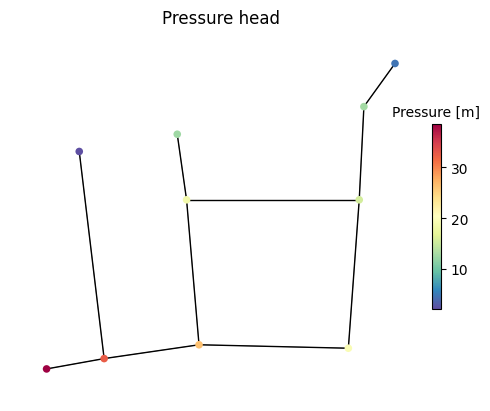

In [20]:
# net_name = "demo.inp"
net_name = "Assignment_1_LDAG_Run3_v1.inp"

# Create water network model and simulate hydraulics
wn = wntr.network.WaterNetworkModel(network_file(net_name))
results = wntr.sim.EpanetSimulator(wn).run_sim()

# Plot pressure head at the first time step
pressure = results.node["pressure"].loc[0, :]
wntr.graphics.plot_network(wn, node_attribute=pressure, title="Pressure head",
                           node_colorbar_label="Pressure [m]", node_size=30);

### Data extraction
We now use WNTR to extract the network data needed for our own hydraulic solver. Note that WNTR converts all quantities to SI units (m, m$^3$/s).

First, get the network elements and simulation information.

In [ ]:
# nt = number of discrete time steps
# nn = number of junction (demand) nodes
# np = number of links
# n0 = number of source (reservoir) nodes

nt = max(int(wn.options.time.duration / wn.options.time.report_timestep), 1)
net_info = {
    "np": wn.num_links,
    "nn": wn.num_junctions,
    "n0": wn.num_reservoirs,
    "nt": nt,
    "junction_names": wn.junction_name_list,
    "reservoir_names": wn.reservoir_name_list,
}
net_info["np"], net_info["nn"], net_info["n0"], net_info["nt"]

Extract link data. `C` is the Hazen-Williams coefficient for pipes and the loss coefficient for valves. For an active throttle control valve (TCV), EPANET uses the valve setting as its loss coefficient.

In [ ]:
links = []
for name, link in wn.links():
    if isinstance(link, wntr.network.Pipe):
        link_type, length, n_exp, C = "pipe", link.length, 1.852, link.roughness
    else:
        is_tcv = link.valve_type == "TCV" and link.initial_status != wntr.network.LinkStatus.Closed
        link_type, length, n_exp = "valve", 0.0, 2.0
        C = link.initial_setting if is_tcv else link.minor_loss
    links.append({
        "link_ID": name, "link_type": link_type, "diameter": link.diameter, "length": length,
        "n_exp": n_exp, "C": C, "node_out": link.start_node_name, "node_in": link.end_node_name,
    })

link_df = pd.DataFrame(links)
link_df

Extract node data. Reservoirs have no elevation, so we set it to zero.

In [ ]:
node_df = pd.DataFrame([
    {"node_ID": name, "elev": getattr(node, "elevation", 0.0),
     "xcoord": node.coordinates[0], "ycoord": node.coordinates[1]}
    for name, node in wn.nodes()
])
node_df

Build the incidence matrices. Each link has $-1$ in the column of its start node and $+1$ in the column of its end node. We split the columns into junctions ($A_{12}$) and reservoirs ($A_{10}$).

In [ ]:
node_idx = {name: i for i, name in enumerate(node_df["node_ID"])}
A = np.zeros((net_info["np"], len(node_df)))
for k, row in link_df.iterrows():
    A[k, node_idx[row["node_out"]]] = -1
    A[k, node_idx[row["node_in"]]] = 1

A12 = sp.csr_matrix(A[:, [node_idx[n] for n in net_info["junction_names"]]])  # link-junction
A10 = sp.csr_matrix(A[:, [node_idx[n] for n in net_info["reservoir_names"]]])  # link-reservoir
A12.shape, A10.shape

Extract operational data: junction demands and reservoir (boundary) heads. EPANET reports results at the start and end of the simulation period ($n_t + 1$ times), so we keep the first $n_t$.

In [ ]:
# demand data (junctions only)
demand_df = results.node["demand"][net_info["junction_names"]].iloc[:nt].T
demand_df.columns = [f"demands_{t}" for t in range(1, nt + 1)]
demand_df = demand_df.rename_axis("node_ID").reset_index()
demand_df

In [ ]:
# boundary head data (reservoirs only)
h0_df = results.node["head"][net_info["reservoir_names"]].iloc[:nt].T
h0_df.columns = [f"h0_{t}" for t in range(1, nt + 1)]
h0_df = h0_df.rename_axis("node_ID").reset_index()
h0_df

> **Note:** the code above is packaged as the functions `load_network_data` and `plot_network` in `src/opwater/network.py`.

## Newton-Raphson hydraulic solver
We now develop our own hydraulic solver using the Newton-Raphson method for solving systems of nonlinear equations.

### System of nonlinear equations
Hydraulic states are computed for each time step $t \in \lbrace 1, \dots, n_t \rbrace$, where $n_t$ is the number of discrete time steps in the simulation period. The unknown variables are:
- flow rates $q_t \in \mathbb{R}^{n_p}$ in the network links, where $n_p$ is the number of links;
- hydraulic heads $h_t \in \mathbb{R}^{n_n}$ at the network junctions, where $n_n$ is the number of junctions.

Their solution is governed by the **energy** and **mass** conservation equations:

$$
\begin{aligned}
A_{11}(q_t)q_t + A_{12}h_t + A_{10}h_{0,t} &= 0 \\
A_{12}^T q_t - d_t &= 0,
\end{aligned}
\tag{1}
$$

where
- $A_{11}(q) \in \mathbb{R}^{n_p \times n_p}$ is a diagonal matrix with elements $R_j|q_j|^{n_j-1}$, where $R_j$ is the resistance coefficient and $n_j$ the head loss exponent of pipe or valve $j \in \lbrace 1, \dots, n_p \rbrace$
- $A_{12} \in \mathbb{R}^{n_p \times n_n}$ is the link-junction incidence matrix
- $A_{21} = A_{12}^T \in \mathbb{R}^{n_n \times n_p}$ is the junction-link incidence matrix
- $A_{10} \in \mathbb{R}^{n_p \times n_0}$ is the link-reservoir incidence matrix, where $n_0$ is the number of reservoirs (known heads)
- $d_t \in \mathbb{R}^{n_n}$ is the vector of known demands (loading conditions)
- $h_{0,t} \in \mathbb{R}^{n_0}$ is the vector of known heads (boundary conditions)

We omit the time index $t$ from here on, since the same equations are solved at every time step. In matrix form, the system of nonlinear equations (1) is

$$
F(q,h) :=
\begin{bmatrix} A_{11}(q) & A_{12} \\ A_{12}^T & 0 \end{bmatrix}
\begin{bmatrix} q \\ h \end{bmatrix}
-
\begin{bmatrix} -A_{10}h_0 \\ d \end{bmatrix}
= 0.
\tag{2}
$$

### Newton-Raphson method
The Newton-Raphson method is an iterative numerical technique for finding a root of $F(x) = 0$. At each iteration $k$, a new estimate of the root is found using

$$
x^{k+1} = x^k - J(x^k)^{-1}F(x^k),
\tag{3}
$$

where $J(x)$ is the Jacobian, the matrix of first-order partial derivatives. In general, if $F(x)$ has $m$ equations $f_1, \dots, f_m$ in $n$ variables $x_1, \dots, x_n$,

$$
F(x) = \begin{bmatrix} f_1(x_1, \dots, x_n) \\ \vdots \\ f_m(x_1, \dots, x_n) \end{bmatrix},
\tag{4}
$$

then the Jacobian is

$$
J(x) = \begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \frac{\partial f_1}{\partial x_2} & \cdots & \frac{\partial f_1}{\partial x_n} \\
\frac{\partial f_2}{\partial x_1} & \frac{\partial f_2}{\partial x_2} & \cdots & \frac{\partial f_2}{\partial x_n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial f_m}{\partial x_1} & \frac{\partial f_m}{\partial x_2} & \cdots & \frac{\partial f_m}{\partial x_n}
\end{bmatrix}.
\tag{5}
$$

### Hydraulic solver
We now define the Jacobian and Newton-Raphson steps for the hydraulic equations (1). The system of nonlinear equations

$$
F(q, h) := \begin{cases}
f_1(q,h) = A_{11}(q)q + A_{12}h + A_{10}h_0 = 0 \\
f_2(q,h) = A_{12}^T q - d = 0
\end{cases}
\tag{6}
$$

has partial derivatives

$$
\begin{aligned}
\frac{\partial f_1}{\partial q} &= \frac{\partial \left(A_{11}(q)q\right)}{\partial q} = \operatorname{diag}\left(n_j R_j |q_j|^{n_j-1}\right) = N A_{11}(q), &
\frac{\partial f_1}{\partial h} &= A_{12}, \\
\frac{\partial f_2}{\partial q} &= A_{12}^T, &
\frac{\partial f_2}{\partial h} &= 0,
\end{aligned}
\tag{7}
$$

which gives the Jacobian

$$
J(q,h) = \begin{bmatrix} N A_{11}(q) & A_{12} \\ A_{12}^T & 0 \end{bmatrix},
\quad \text{where} \quad
N = \begin{bmatrix} n_1 & & \\ & \ddots & \\ & & n_{n_p} \end{bmatrix}.
\tag{8}
$$

Computing the inverse of the Jacobian at every iteration is inefficient. We therefore multiply both sides of (3) by $J(x^k)$ to remove the inverse:

$$
J(x^k)x^{k+1} = J(x^k)x^k - F(x^k).
\tag{9}
$$

Each new iterate is then found by solving the linear system

$$
\begin{bmatrix} NA_{11}(q^k) & A_{12} \\ A_{12}^T & 0 \end{bmatrix}
\begin{bmatrix} q^{k+1} \\ h^{k+1} \end{bmatrix}
=
\begin{bmatrix} NA_{11}(q^k) & A_{12} \\ A_{12}^T & 0 \end{bmatrix}
\begin{bmatrix} q^k \\ h^k \end{bmatrix}
-
\left(
\begin{bmatrix} A_{11}(q^k) & A_{12} \\ A_{12}^T & 0 \end{bmatrix}
\begin{bmatrix} q^k \\ h^k \end{bmatrix}
+
\begin{bmatrix} A_{10}h_0 \\ -d \end{bmatrix}
\right),
\tag{10}
$$

which simplifies to

$$
\begin{bmatrix} NA_{11}(q^k) & A_{12} \\ A_{12}^T & 0 \end{bmatrix}
\begin{bmatrix} q^{k+1} \\ h^{k+1} \end{bmatrix}
=
\begin{bmatrix} (N-I)A_{11}(q^k)q^k - A_{10}h_0 \\ d \end{bmatrix}.
\tag{11}
$$

Note that the right-hand side depends only on $q^k$, so only an initial guess of the flows $q^0$ is needed.

At each iteration $k$, we check for convergence:

$$
\left\lVert
\begin{matrix}
A_{11}(q^{k+1})q^{k+1} + A_{12}h^{k+1} + A_{10}h_0 \\
A_{12}^Tq^{k+1} - d
\end{matrix}
\right\rVert_{\infty} < \epsilon_{\text{tol}},
\tag{12}
$$

i.e. the solver has converged when the largest energy or mass balance error is below a tolerance $\epsilon_{\text{tol}}$.

The solution process is:
1. Input network data and compute the resistance coefficients $R_j$.
2. Set the boundary conditions $d$, $h_0$ and initial flows $q^0$; set $k = 0$.
3. Solve the linear system (11) for $q^{k+1}$ and $h^{k+1}$.
4. Update $A_{11}(q^{k+1})$ and check convergence (12). If converged, stop; otherwise set $k = k + 1$ and return to step 3.

The code below implements the Newton-Raphson solver. First, we load the network data with `load_network_data` (the extraction code from above, packaged as a function) and plot the network.

In [ ]:
# net_name = "demo.inp"
net_name = "stkl.inp"

wdn = load_network_data(network_file(net_name))
plot_network(wdn);

In [ ]:
### Step 1: network data, loss coefficients and solver settings
A12, A10 = wdn.A12, wdn.A10
link_df, demand_df, h0_df = wdn.link_df, wdn.demand_df, wdn.h0_df
n_links, n_nodes, nt = wdn.net_info["np"], wdn.net_info["nn"], wdn.net_info["nt"]

# resistance coefficients: Hazen-Williams for pipes, minor loss for valves (length and diameter in m)
pipe_K = 10.67 * link_df["length"] * link_df["C"] ** -link_df["n_exp"] * link_df["diameter"] ** -4.8704
valve_K = 8 / (np.pi**2 * 9.81) * link_df["diameter"] ** -4 * link_df["C"]
K = np.where(link_df["link_type"] == "pipe", pipe_K, valve_K).reshape(-1, 1)
n_exp = link_df["n_exp"].to_numpy().reshape(-1, 1)

tol = 1e-5  # convergence tolerance
kmax = 50  # maximum iterations
tol_A11 = 1e-5  # lower bound on A11, since small values make convergence unsteady (Todini and Pilati, 1988)

N = sp.diags(n_exp.ravel())
I = sp.eye(n_links)
Z = sp.csr_matrix((n_nodes, n_nodes))

q = np.zeros((n_links, nt))
h = np.zeros((n_nodes, nt))

for t in range(nt):
    ### Step 2: boundary conditions and initial flows
    d = demand_df.iloc[:, t + 1].to_numpy().reshape(-1, 1)
    h0 = h0_df.iloc[:, t + 1].to_numpy().reshape(-1, 1)
    qk = 0.03 * np.ones((n_links, 1))
    A11 = sp.diags(np.maximum(K * np.abs(qk) ** (n_exp - 1), tol_A11).ravel())

    for k in range(kmax):
        ### Step 3: solve the linear system (11) for q^{k+1} and h^{k+1}
        J = sp.bmat([[N @ A11, A12], [A12.T, Z]], format="csc")
        b = np.vstack([(N - I) @ A11 @ qk - A10 @ h0, d])
        x = spla.spsolve(J, b).reshape(-1, 1)
        qk, hk = x[:n_links], x[n_links:]

        ### Step 4: update A11 and check convergence (12)
        A11 = sp.diags(np.maximum(K * np.abs(qk) ** (n_exp - 1), tol_A11).ravel())
        max_err = max(np.abs(A11 @ qk + A12 @ hk + A10 @ h0).max(), np.abs(A12.T @ qk - d).max())
        if max_err < tol:
            break

    print(f"Time step {t + 1}: {k + 1} iterations, error = {max_err:.1e}")
    q[:, t] = qk.ravel()
    h[:, t] = hk.ravel()

> **Note:** the code above is packaged as `hydraulic_solver(wdn, method="nr")` in `src/opwater/hydraulics.py`.

## Newton-Raphson solver with the Schur complement
The linear system (11) has a *saddle point* structure. We can exploit this structure to make the Newton-Raphson solver faster.

### Saddle point problems
A linear system in saddle point form is written as

$$
\begin{bmatrix} A & B_1 \\ B_2^T & C \end{bmatrix}
\begin{bmatrix} x \\ y \end{bmatrix}
=
\begin{bmatrix} f \\ g \end{bmatrix},
\quad \text{or} \quad \mathcal{A}u = b,
\tag{13}
$$

where the blocks typically satisfy:
1. $A$ is symmetric positive semidefinite ($A \succeq 0$)
2. $B_1 = B_2 = B$
3. $C$ is symmetric positive semidefinite ($C \succeq 0$)

In the Newton-Raphson step (11):
- $A = NA_{11}(q^k)$
- $B = A_{12}$
- $C = 0$ (zero matrix)
- $x = q^{k+1}$
- $y = h^{k+1}$
- $f = (N-I)A_{11}(q^k)q^k - A_{10}h_0$
- $g = d$

### Block factorisation and the Schur complement
If $A$ is nonsingular, the saddle point matrix $\mathcal{A}$ (with $C = 0$) admits the following block factorisations:

$$
\mathcal{A}
= \begin{bmatrix} A & B_1 \\ B_2^T & 0 \end{bmatrix}
= \begin{bmatrix} I & 0 \\ B_2^TA^{-1} & I \end{bmatrix}
\begin{bmatrix} A & 0 \\ 0 & S \end{bmatrix}
\begin{bmatrix} I & A^{-1}B_1 \\ 0 & I \end{bmatrix}
\tag{14}
$$

$$
\mathcal{A} = \begin{bmatrix} A & 0 \\ B_2^T & S \end{bmatrix}
\begin{bmatrix} I & A^{-1}B_1 \\ 0 & I \end{bmatrix}
\tag{15}
$$

$$
\mathcal{A} = \begin{bmatrix} I & 0 \\ B_2^TA^{-1} & I \end{bmatrix}
\begin{bmatrix} A & B_1 \\ 0 & S \end{bmatrix}
\tag{16}
$$

where

$$
S = -B_2^TA^{-1}B_1
$$

is the **Schur complement** of $A$ in $\mathcal{A}$. For our hydraulic problem,

$$
S = -A_{12}^T\left(NA_{11}(q^k)\right)^{-1}A_{12}.
$$

The following conditions ensure that $S$ and $\mathcal{A}$ are nonsingular:
1. $A$ is symmetric positive definite
2. $B$ has full column rank
3. $\ker(A) \cap \ker(B^T) = \lbrace 0 \rbrace$

We do not prove here that these conditions hold for (11). Note that the lower bound `tol_A11` on the diagonal elements of $A_{11}$ (introduced above) keeps $A_{11}$ positive definite, and therefore invertible, with negligible effect on energy conservation.

### Applying the Schur complement to the Newton-Raphson step
Recall the linear system solved at each Newton-Raphson step:

$$
\begin{bmatrix} NA_{11}(q^k) & A_{12} \\ A_{12}^T & 0 \end{bmatrix}
\begin{bmatrix} q^{k+1} \\ h^{k+1} \end{bmatrix}
=
\begin{bmatrix} (N-I)A_{11}(q^k)q^k - A_{10}h_0 \\ d \end{bmatrix}.
\tag{17}
$$

Written out in full, this is

$$
\begin{aligned}
NA_{11}(q^k)q^{k+1} + A_{12}h^{k+1} &= (N-I)A_{11}(q^k)q^k - A_{10}h_0 \\
A_{12}^Tq^{k+1} &= d.
\end{aligned}
\tag{18}
$$

Multiplying the first equation by $A_{12}^T\left(NA_{11}(q^k)\right)^{-1}$ and substituting $A_{12}^Tq^{k+1} = d$ gives

$$
\begin{aligned}
&A_{12}^T\left(NA_{11}(q^k)\right)^{-1}A_{12}h^{k+1} \\
&\qquad = A_{12}^T\left(NA_{11}(q^k)\right)^{-1}\left((N-I)A_{11}(q^k)q^k - A_{10}h_0\right) - d.
\end{aligned}
\tag{19}
$$

Finally, since $\left(NA_{11}(q^k)\right)^{-1} = N^{-1}A_{11}(q^k)^{-1}$ (both are diagonal), we have

$$
\begin{aligned}
&A_{12}^TN^{-1}A_{11}(q^k)^{-1}A_{12}h^{k+1} \\
&\qquad = -A_{12}^TN^{-1}\left(q^k + A_{11}(q^k)^{-1}A_{10}h_0\right) + A_{12}^Tq^k - d.
\end{aligned}
\tag{20}
$$

We solve (20) for $h^{k+1}$. The matrix $A_{12}^TN^{-1}A_{11}(q^k)^{-1}A_{12}$ (the negative of the Schur complement) is symmetric positive definite and much smaller ($n_n \times n_n$) than the Jacobian ($(n_p+n_n) \times (n_p+n_n)$). Its structure also allows fast factorisation algorithms, such as the Cholesky factorisation.

Once $h^{k+1}$ is known, $q^{k+1}$ is found by rearranging the first equation in (18):

$$
q^{k+1} = (I - N^{-1})q^k - N^{-1}A_{11}(q^k)^{-1}\left(A_{12}h^{k+1} + A_{10}h_0\right).
\tag{21}
$$

This solver is known as the global gradient algorithm (GGA), the "nodal" version of the Newton-Raphson method. It is the algorithm used in EPANET.

The code below implements the Newton-Raphson solver with the Schur complement, reusing the network data and settings from Step 1 above. Only Step 3 differs from the previous solver.

In [ ]:
inv_N = sp.diags(1 / n_exp.ravel())

q = np.zeros((n_links, nt))
h = np.zeros((n_nodes, nt))

for t in range(nt):
    ### Step 2: boundary conditions and initial flows
    d = demand_df.iloc[:, t + 1].to_numpy().reshape(-1, 1)
    h0 = h0_df.iloc[:, t + 1].to_numpy().reshape(-1, 1)
    qk = 0.03 * np.ones((n_links, 1))
    A11 = sp.diags(np.maximum(K * np.abs(qk) ** (n_exp - 1), tol_A11).ravel())

    for k in range(kmax):
        ### Step 3: solve (20) for h^{k+1}, then compute q^{k+1} from (21)
        inv_A11 = sp.diags(1 / A11.diagonal())
        DD = inv_N @ inv_A11  # (N A11)^{-1}
        S = (A12.T @ DD @ A12).tocsc()  # (negative) Schur complement
        b = -A12.T @ inv_N @ (qk + inv_A11 @ A10 @ h0) + A12.T @ qk - d
        hk = spla.spsolve(S, b).reshape(-1, 1)
        qk = (I - inv_N) @ qk - DD @ (A12 @ hk + A10 @ h0)

        ### Step 4: update A11 and check convergence (12)
        A11 = sp.diags(np.maximum(K * np.abs(qk) ** (n_exp - 1), tol_A11).ravel())
        max_err = max(np.abs(A11 @ qk + A12 @ hk + A10 @ h0).max(), np.abs(A12.T @ qk - d).max())
        if max_err < tol:
            break

    print(f"Time step {t + 1}: {k + 1} iterations, error = {max_err:.1e}")
    q[:, t] = qk.ravel()
    h[:, t] = hk.ravel()

> **Note:** the code above is packaged as `hydraulic_solver(wdn, method="nr_schur")` in `src/opwater/hydraulics.py`.

## Questions
Use the functions from this notebook to answer the questions below. Complete the code cells marked `TODO`.

### Q1. Solver comparison
Run the three solvers on the `stkl` network:
- `hydraulic_solver(wdn, method="nr")`: Newton-Raphson
- `hydraulic_solver(wdn, method="nr_schur")`: Newton-Raphson with the Schur complement
- `epanet_solver(network_file(net_name))`: EPANET, via `wntr.sim.EpanetSimulator`

Each returns flows `q` [m$^3$/s] and heads `h` [m] as DataFrames: an ID column, then one column per time step. To plot results on the network, use e.g. `plot_network(wdn, plot_type="pressure head", vals=h_nr, t=8)`.

(a) Compare the computation times. Which solver is fastest, and why? Does this change for `demo.inp`?

(b) Compare the flows and heads from your two solvers with those from EPANET. How large are the differences?

In [ ]:
net_name = "stkl.inp"  # or "demo.inp"
wdn = load_network_data(network_file(net_name))

start_time = time.perf_counter()
q_nr, h_nr = hydraulic_solver(wdn, method="nr")
cpu_time_nr = time.perf_counter() - start_time

# TODO: time the Schur complement solver and EPANET in the same way

In [ ]:
# TODO: compare flows and heads with EPANET (q_nr.iloc[:, 1:] drops the ID column)

### Q2. Field data comparison
The file `stkl_field_data.npz` contains 192 hourly time steps of field data for the `stkl` network:
- `h_data`: measured heads at the pressure sensors [m], one row per sensor
- `sensor_idx`: junction index (0-based) of each sensor
- `d`: junction demands [m$^3$/s]
- `h0`: reservoir head [m]

The code below plots the sensor locations and replaces the demands and reservoir heads in `wdn` with the measured values. Simulate the network with one of the solvers from Q1, then compute and plot the residuals (simulated minus measured head) at each sensor. Comment on their:

(a) sign: does the model over- or underestimate heads?

(b) temporal distribution: do the residuals vary over time?

(c) spatial distribution: are all sensors affected equally?

What might cause these differences?

In [ ]:
net_name = "stkl.inp"
data = np.load(data_dir() / "field" / "stkl_field_data.npz")
h_data, sensor_idx = data["h_data"], data["sensor_idx"]

wdn = load_network_data(network_file(net_name))
plot_network(wdn, sensor_nodes=sensor_idx)

# replace the network's demands and reservoir heads with the field data
nt = h_data.shape[1]
wdn.net_info["nt"] = nt
wdn.demand_df = pd.concat(
    [wdn.demand_df["node_ID"], pd.DataFrame(data["d"], columns=[f"demands_{t}" for t in range(1, nt + 1)])],
    axis=1,
)
wdn.h0_df = pd.concat(
    [wdn.h0_df["node_ID"], pd.DataFrame(data["h0"], columns=[f"h0_{t}" for t in range(1, nt + 1)])],
    axis=1,
)

In [ ]:
# TODO: simulate the network, extract the heads at the sensors (rows sensor_idx of the head results),
# then compute and plot the residuals

### Q3. Tanks
Our solver treats reservoirs as fixed heads. A tank also supplies water, but it stores a finite volume, so its head changes over time. EPANET example network 2 (`Net2.inp`) has one tank, no reservoirs and no pumps.

(a) Within a single time step, how can the tank be included in the hydraulic equations (1)?

(b) How should the tank head be updated between time steps? Write the equation in terms of the tank's diameter, the time step $\Delta t$ and the flows in the pipes connected to the tank.

(c) *Optional:* extend the Newton-Raphson solver to include the tank, and compare your tank heads with EPANET's (plotted below). Note that `load_network_data` ignores tanks: they appear in neither $A_{12}$ nor $A_{10}$.

In [ ]:
net_name = "Net2.inp"
wn = wntr.network.WaterNetworkModel(network_file(net_name))
tank = wn.get_node(wn.tank_name_list[0])
print(f"Tank {tank.name}: elevation {tank.elevation:.1f} m, initial level {tank.init_level:.1f} m, "
      f"diameter {tank.diameter:.1f} m")

results = wntr.sim.EpanetSimulator(wn).run_sim()
tank_head = results.node["head"][tank.name]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tank_head.index / 3600, tank_head)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Tank head [m]")
ax.set_title("EPANET");

## References
- Rossman, L., Woo, H., Tryby, M., Shang, F., Janke, R., and Haxton, T. (2020). *EPANET 2.2 User Manual*. U.S. Environmental Protection Agency.
- Klise, K.A., Bynum, M., Moriarty, D., and Murray, R. (2017). A software framework for assessing the resilience of drinking water systems to disasters with an example earthquake case study. *Environmental Modelling and Software*, 95, 420–431. doi: 10.1016/j.envsoft.2017.06.022
- Todini, E. and Pilati, S. (1988). A gradient algorithm for the analysis of pipe networks. In B. Coulbeck and O. Chun-Hou (eds.), *Computer Applications in Water Supply, Vol. I: System Analysis and Simulation*, 1–20. Wiley, London.
- Abraham, E. and Stoianov, I. (2016). Sparse null space algorithms for hydraulic analysis of large-scale water supply networks. *Journal of Hydraulic Engineering*, 142(3), 04015058.